# Assignment 1_CopperPlate:

# Step 1 – Copper-Plate Market Clearing (Single Hour)

## Market-Clearing Mechanism

The market-clearing problem maximizes social welfare:

$$
\max \left(
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}
\right)
$$

subject to the power balance constraint:

$$
\sum_{i \in \mathcal{G}} p_{i,t}
+
\sum_{w \in \mathcal{W}} p_{w,t}
=
\sum_{d \in \mathcal{D}} d_{d,t}.
$$

The dual variable associated with the power balance constraint is the market-clearing price:

$$
\lambda_t.
$$

Under uniform pricing, all accepted generators and demands are settled at this price.

---

## Merit-Order Dispatch

Conventional generators are dispatched according to increasing marginal costs $C_i$.

The economic logic is:

- If $C_i < \lambda_t$ → the generator is **fully dispatched**.
- If $C_i = \lambda_t$ → the generator is **marginal** (partially dispatched).
- If $C_i > \lambda_t$ → the generator is **not dispatched**.

Renewable generators (wind) are modeled with zero marginal cost:

$$
C_w = 0,
$$

and are therefore dispatched up to their available capacity:

$$
0 \le p_{w,t} \le \bar{P}_{w,t}.
$$

---

## Welfare Decomposition

Social welfare is defined as:

$$
SW =
\sum_{d \in \mathcal{D}} U_d d_{d,t}
-
\sum_{i \in \mathcal{G}} C_i p_{i,t}.
$$

Producer profit for generator $i$:

$$
\Pi_i = (\lambda_t - C_i) p_{i,t}.
$$

Demand utility for consumer $d$:

$$
\text{Utility}_d = d_{d,t}(U_d - \lambda_t).
$$

Infra-marginal generators earn positive profits, while the marginal generator earns zero profit.

---

## KKT Conditions and Price Formation

The stationarity condition for each generator is:

$$
C_i - \lambda_t + \mu_i^{\max} - \mu_i^{\min} = 0,
$$

where:

- $\mu_i^{\max}$ is the multiplier of the upper bound constraint,
- $\mu_i^{\min}$ is the multiplier of the lower bound constraint.

Three cases arise:

1. **Marginal unit:**  
   $p_{i,t} > 0$ and not at a bound  
   $$C_i = \lambda_t.$$

2. **Infra-marginal unit (capacity constrained):**  
   $p_{i,t} = P_i^{\max}$  
   $$C_i < \lambda_t.$$

3. **Rejected unit:**  
   $p_{i,t} = 0$  
   $$C_i > \lambda_t.$$

Thus, the market-clearing price equals the marginal accepted bid, confirming the economic interpretation of the dual variable $\lambda_t$.

In [1]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import os

# ============================================
# SETS
# ============================================

G = range(12)         # i ∈ 𝒢 (conventional generators)
W = [0]               # w ∈ 𝒲 (single aggregated wind unit)
D_set = [0]           # d ∈ 𝒟 (single aggregated demand)

# ============================================
# PARAMETERS
# ============================================

# Generator parameters
P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Demand parameters
D_t = 2650.5          # total system demand
U_d = 100             # demand bid price

# ============================================
# WIND DATA IMPORT
# ============================================
wind_file = os.path.join("data", "processed", "wind_capacity_factor_2024_avg.csv")  #change path from your specific one

wind_data = pd.read_csv(wind_file)


# Choose hour with maximum wind availability
t_star = wind_data["available_wind_MW"].idxmax()
hour_star = wind_data.loc[t_star, "hour"]

P_w_bar = wind_data.loc[
    wind_data["hour"] == hour_star,
    "available_wind_MW"
].values[0]

# ============================================
# REPORT INPUT SUMMARY
# ============================================

print("\n========== INPUT SUMMARY ==========")
print(f"Selected hour (wind peak): t = {hour_star}")
print(f"Total demand D_t: {D_t:.2f} MW")
print(f"Wind availability P̄_w,t: {P_w_bar:.2f} MW")
print(f"Demand bid U_d: {U_d:.2f} €/MWh")

total_capacity = sum(P_max[i] for i in G)
print(f"Total conventional capacity Σ P_i^max: {total_capacity:.2f} MW")



========== INPUT SUMMARY ==========
Selected hour (wind peak): t = 12
Total demand D_t: 2650.50 MW
Wind availability P̄_w,t: 173.73 MW
Demand bid U_d: 100.00 €/MWh
Total conventional capacity Σ P_i^max: 3375.00 MW


In [2]:
# ============================================
# MODEL
# ============================================

model = gp.Model("CopperPlate_Market")

# Decision variables
p_i = model.addVars(G, lb=0,
                    ub=[P_max[i] for i in G],
                    name="p_i")

p_w = model.addVar(lb=0, ub=P_w_bar, name="p_w")

d_d = model.addVar(lb=0, ub=D_t, name="d_d")

# Objective: minimize (generation cost − utility)
model.setObjective(
    gp.quicksum(C[i] * p_i[i] for i in G)
    - U_d * d_d,
    GRB.MINIMIZE
)

# Power balance
balance = model.addConstr(
    gp.quicksum(p_i[i] for i in G) + p_w == d_d,
    name="power_balance"
)

model.optimize()



Set parameter Username
Set parameter LicenseID to value 2783196


Academic license - for non-commercial use only - expires 2027-02-25
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 14 columns and 14 nonzeros
Model fingerprint: 0xc1826593
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+02]
  Bounds range     [6e+01, 3e+03]
  RHS range        [0e+00, 0e+00]
Presolve removed 0 rows and 4 columns
Presolve time: 0.02s
Presolved: 1 rows, 10 columns, 10 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.6505000e+05   2.720968e+02   0.000000e+00      0s
       1   -2.4394339e+05   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.04 seconds (0.00 work units)
Optimal objective -2.439433885e+05


In [6]:
# ============================================
# RESULTS
# ============================================

if model.status == GRB.OPTIMAL:

    print("\n========== MARKET CLEARING RESULTS ==========\n")

    # Market-clearing price λ_t
    lambda_t = balance.Pi
    print(f"Market clearing price λ_t: {lambda_t:.2f} €/MWh")

    print(f"\nWind production p_w,t: {p_w.X:.2f} MW")
    print(f"Demand served d_d,t: {d_d.X:.2f} MW")

    # Total operating cost
    total_cost = sum(C[i] * p_i[i].X for i in G)
    print(f"\nTotal operating cost: {total_cost:.2f} €")

    # Social welfare
    social_welfare = U_d * d_d.X - total_cost
    print(f"Social welfare: {social_welfare:.2f} €")

    # Producer profits
    print("\nProducer profits Π_i:")
    for i in G:
        profit_i = lambda_t * p_i[i].X - C[i] * p_i[i].X
        print(f"Unit {i+1}: {profit_i:.2f} €")

    # Wind profit
    wind_profit = lambda_t * p_w.X
    print(f"\nWind profit: {wind_profit:.2f} €")

    # Demand utility
    utility_d = d_d.X * (U_d - lambda_t)
    print(f"Demand utility: {utility_d:.2f} €")

    # ============================================
    # KKT CHECK
    # ============================================

    print("\n========== KKT CHECK ==========\n")

    for i in G:
        print(f"Unit {i+1}:")
        print(f"  p_i,t = {p_i[i].X:.2f}")
        print(f"  Reduced cost = {p_i[i].RC:.6f}")


========== MARKET CLEARING RESULTS ==========

Market clearing price λ_t: 20.70 €/MWh

Wind production p_w,t: 173.73 MW
Demand served d_d,t: 2650.50 MW

Total operating cost: 21106.61 €
Social welfare: 243943.39 €

Producer profits Π_i:
Unit 1: 1121.76 €
Unit 2: 1121.76 €
Unit 3: 0.00 €
Unit 4: 0.00 €
Unit 5: 0.00 €
Unit 6: 1577.90 €
Unit 7: 1577.90 €
Unit 8: 5872.00 €
Unit 9: 6092.00 €
Unit 10: 6210.00 €
Unit 11: 3155.80 €
Unit 12: 3433.50 €

Wind profit: 3596.12 €
Demand utility: 210184.65 €

========== KKT CHECK ==========

Unit 1:
  p_i,t = 152.00
  Reduced cost = -7.380000
Unit 2:
  p_i,t = 152.00
  Reduced cost = -7.380000
Unit 3:
  p_i,t = 102.77
  Reduced cost = 0.000000
Unit 4:
  p_i,t = 0.00
  Reduced cost = 0.230000
Unit 5:
  p_i,t = 0.00
  Reduced cost = 5.410000
Unit 6:
  p_i,t = 155.00
  Reduced cost = -10.180000
Unit 7:
  p_i,t = 155.00
  Reduced cost = -10.180000
Unit 8:
  p_i,t = 400.00
  Reduced cost = -14.680000
Unit 9:
  p_i,t = 400.00
  Reduced cost = -15.230000
U

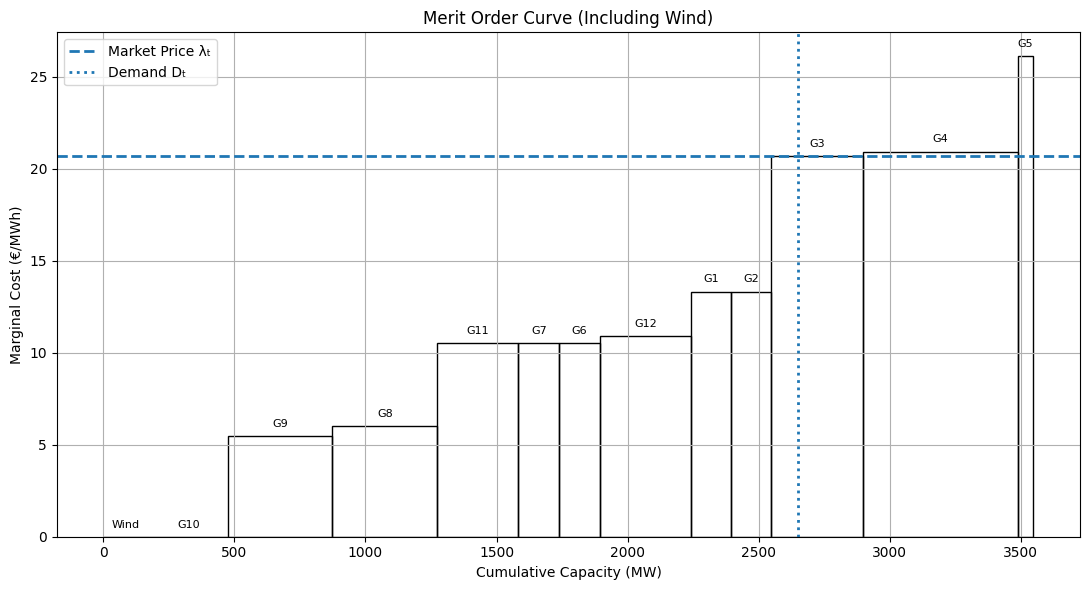

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------
# Generator Data
# -------------------------------

gen_data = pd.DataFrame({
    "unit": [f"G{i}" for i in range(1, 13)],
    "Pmax": [152, 152, 350, 591, 60, 155, 155, 400, 400, 300, 310, 350],
    "cost": [13.32, 13.32, 20.70, 20.93, 26.11, 10.52, 10.52,
             6.02, 5.47, 0.00, 10.52, 10.89]
})

# Wind block (from model)
P_w_bar = 173.73  # use your computed value
wind_block = pd.DataFrame({
    "unit": ["Wind"],
    "Pmax": [P_w_bar],
    "cost": [0.0]
})

# Combine wind + conventional
supply_data = pd.concat([wind_block, gen_data], ignore_index=True)

# Sort by marginal cost
supply_sorted = supply_data.sort_values("cost").reset_index(drop=True)

# Market price and demand
lambda_t = 20.70
D_t = 2650.5

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(11, 6))

cumulative_capacity = 0

for i in range(len(supply_sorted)):
    capacity = supply_sorted.loc[i, "Pmax"]
    cost = supply_sorted.loc[i, "cost"]
    label = supply_sorted.loc[i, "unit"]

    plt.bar(
        cumulative_capacity,
        cost,
        width=capacity,
        align='edge',
        edgecolor='black',
        fill=False
    )

    plt.text(
        cumulative_capacity + capacity/2,
        cost + 0.5,
        label,
        ha='center',
        fontsize=8
    )

    cumulative_capacity += capacity

# Market clearing price
plt.axhline(lambda_t, linestyle='--', linewidth=2, label="Market Price λₜ")

# Demand
plt.axvline(D_t, linestyle=':', linewidth=2, label="Demand Dₜ")

plt.xlabel("Cumulative Capacity (MW)")
plt.ylabel("Marginal Cost (€/MWh)")
plt.title("Merit Order Curve (Including Wind)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 5 – Balancing Market

## Real-Time Deviations

After the day-ahead market clears, the system moves to real-time operation. 
However, the realized production may differ from the day-ahead schedule due to unforeseen events.

In this step we assume two types of deviations:

1. **Generator outage**

One conventional generator unexpectedly fails and therefore produces zero power in real time.

If generator $k$ experiences an outage:

$$
p_{k}^{real} = 0
$$

2. **Wind forecast error**

Wind production differs from the day-ahead forecast. Some wind farms produce less power than expected,
while others produce more. For simplicity in our aggregated model, we assume the realized wind production is:

$$
p_w^{real} = \alpha \, p_w^{DA}
$$

where $\alpha$ represents the deviation factor.

---

## System Imbalance

The mismatch between demand and realized generation creates a system imbalance:

$$
\Delta = D_t - \left(\sum_i p_i^{real} + p_w^{real}\right)
$$

where:

- $\Delta > 0$ → the system is **short** and requires **upward regulation**
- $\Delta < 0$ → the system is **long** and requires **downward regulation**

The balancing market is then cleared to correct this imbalance.